In [116]:
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow import keras
import os
import numpy as np

### Appliance energy consumption

Effectively same procedure used in the pioneering problem, bikes.

Adapted methods to now use past target values as inputs, autoregressive learning problem.

Observations come in 10-minute grid and will forecast the next `Appliances` value (Wh).

In [117]:
dataset_name = 'Appliances'
target_unit = 'Wh / 10 minutes'
nonnegative_target = True
rolling_window = 7 * 24 * 6
frame = pd.read_csv('appliances/energydata_complete.csv', usecols=['date', 'Appliances'])
frame['date'] = pd.to_datetime(frame['date'])
time_col, target_col, frequency = 'date', 'Appliances', '10min'
series = pd.Series(frame[target_col].to_numpy(dtype=float),
                   index=pd.DatetimeIndex(frame[time_col]), name=target_col).sort_index()
groups = series.groupby(level=0)
series = groups.first().mask(groups.nunique(dropna=False).gt(1))
target = series.asfreq(frequency).replace([np.inf, -np.inf], np.nan)
test_start = int(0.8 * len(target))

development = target.iloc[:test_start]
target.head()

date
2016-01-11 17:00:00    60.0
2016-01-11 17:10:00    60.0
2016-01-11 17:20:00    50.0
2016-01-11 17:30:00    50.0
2016-01-11 17:40:00    60.0
Freq: 10min, Name: Appliances, dtype: float64

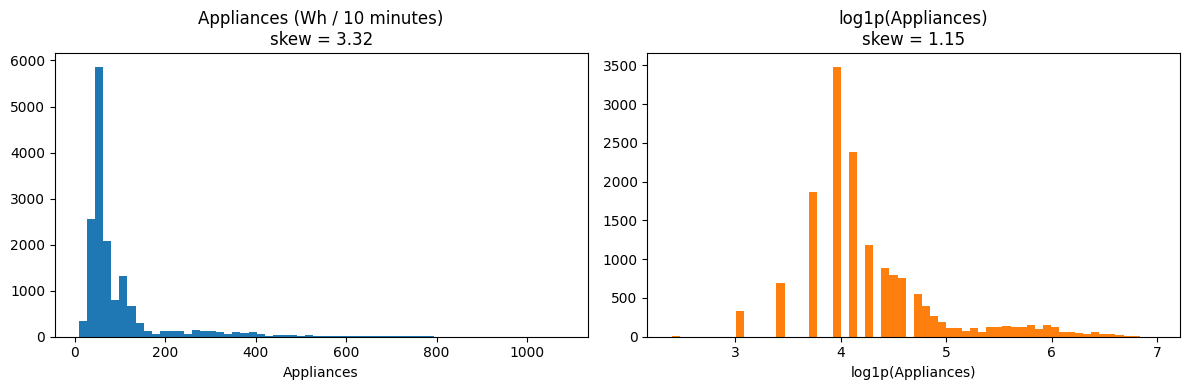

In [118]:
import matplotlib.pyplot as plt
from scipy.stats import skew

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(development.dropna(), bins=60, edgecolor='none')
axes[0].set_title(f'{dataset_name} ({target_unit})\nskew = {skew(development.dropna()):.2f}')
axes[0].set_xlabel(target_col)

log_dev = np.log1p(development.dropna())
axes[1].hist(log_dev, bins=60, edgecolor='none', color='C1')
axes[1].set_title(f'log1p({target_col})\nskew = {skew(log_dev):.2f}')
axes[1].set_xlabel(f'log1p({target_col})')

plt.tight_layout()
plt.show()

### ADF test on sampled long sequence to test for stationarity

Uses the longest contiguous observed segment for ACF and ADF so missing timestamps are not joined together

In [119]:
segments = development.notna().ne(development.notna().shift()).cumsum()
observed = development.dropna()
longest_segment = segments.loc[observed.index].value_counts().idxmax()
diagnostic_series = observed.loc[segments.loc[observed.index].eq(longest_segment)]

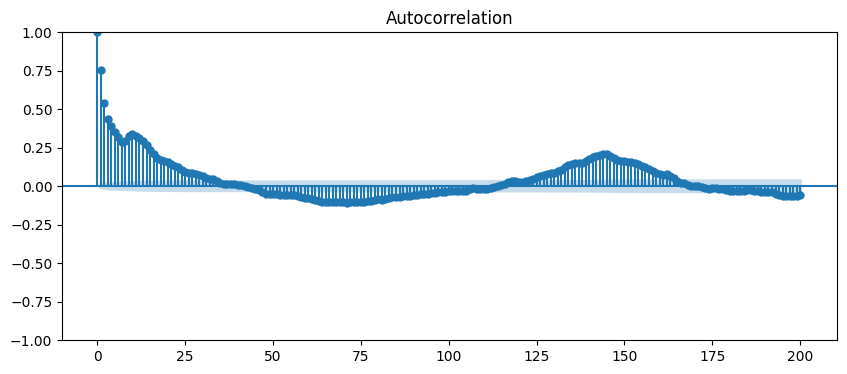

In [120]:
from statsmodels.graphics.tsaplots import plot_acf

fig, ax = plt.subplots(figsize=(10, 4))
plot_acf(diagnostic_series, lags=200, ax=ax)
plt.show()

In [121]:
from statsmodels.tsa.stattools import adfuller

def run_adf(series, label):
    result = adfuller(series.dropna(), autolag='AIC')
    print(f'{label}')
    print(f'  ADF statistic: {result[0]:.4f}')
    print(f'  p-value:       {result[1]:.4f}')
    print(f'  # lags used:   {result[2]}')
    print(f'  # obs used:    {result[3]}')
    for pct, crit in result[4].items():
        print(f'  critical value ({pct}): {crit:.4f}')
    truth = True if result[1] < 0.05 else False
    print(f'  Stationary at 5%? {truth}')
    print()
    return result

adf_result = run_adf(diagnostic_series, 'Raw development target')

Raw development target
  ADF statistic: -19.0101
  p-value:       0.0000
  # lags used:   13
  # obs used:    15774
  critical value (1%): -3.4308
  critical value (5%): -2.8617
  critical value (10%): -2.5669
  Stationary at 5%? True



### Rolling mean and standard deviation

Can be helpful to identify if ADF rejection is false, because seasonal trends obscure adf.

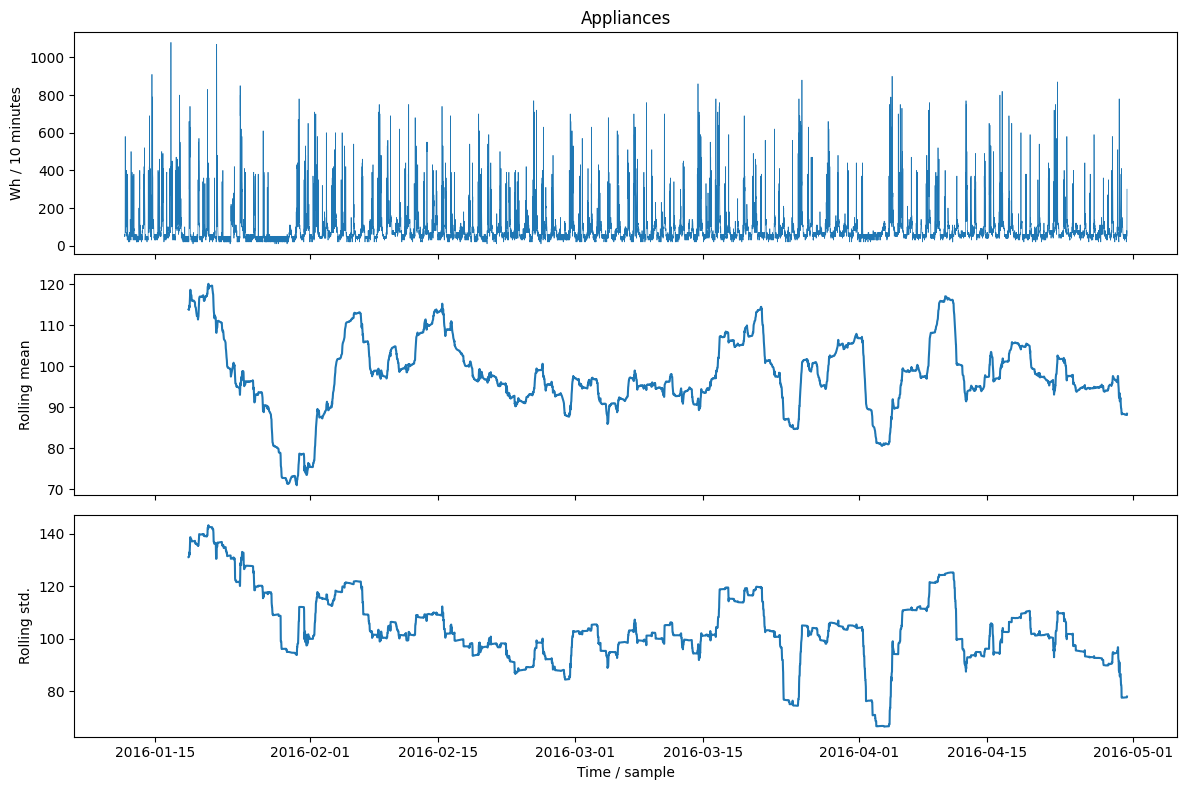

In [122]:
rolling = development.rolling(rolling_window, min_periods=rolling_window)
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].plot(development, linewidth=0.5)
axes[0].set(title=dataset_name, ylabel=target_unit)
axes[1].plot(rolling.mean())
axes[1].set(ylabel='Rolling mean')
axes[2].plot(rolling.std())
axes[2].set(ylabel='Rolling std.', xlabel='Time / sample')
fig.tight_layout()
plt.show()

### Features and target

One feature: past target values

In [123]:
from sklearn.preprocessing import StandardScaler
from IPython.display import display

features = target.to_frame()
assert target.dropna().ge(0).all(), 'log1p requires a nonnegative appliance target.'
target_values = np.log1p(target)
print('Input features:', features.columns.tolist())

Input features: ['Appliances']


### Five separate chronological blocks same as before, friend

In [ ]:
sequence_lengths = [1, 2, 6, 36, 144] 
blocks = []
for positions in np.array_split(np.arange(test_start), 5):
    start, end = int(positions[0]), int(positions[-1] + 1)
    train_end = start + int(0.8 * (end - start))
    blocks.append((start, train_end, end))

display(pd.DataFrame([
    {'fold': i + 1, 'block_start': target.index[start],
     'early_stop_start': target.index[start + int(0.85 * (train_end - start))],
     'validation_start': target.index[train_end], 'block_end': target.index[end - 1]}
    for i, (start, train_end, end) in enumerate(blocks)
]))

,fold,block_start,early_stop_start,validation_start,block_end
0,1,2016-01-11 17:00:00,2016-01-26 14:50:00,2016-01-29 06:00:00,2016-02-02 15:10:00
1,2,2016-02-02 15:20:00,2016-02-17 13:10:00,2016-02-20 04:20:00,2016-02-24 13:30:00
2,3,2016-02-24 13:40:00,2016-03-10 11:30:00,2016-03-13 02:40:00,2016-03-17 11:50:00
3,4,2016-03-17 12:00:00,2016-04-01 09:40:00,2016-04-04 00:50:00,2016-04-08 10:00:00
4,5,2016-04-08 10:10:00,2016-04-23 07:50:00,2016-04-25 23:00:00,2016-04-30 08:10:00


## Pre-processing
`log1p(Appliances)` as the model target. Inputs remain past appliance levels. 

In [125]:
def prepare_block(start, train_end, end, length):
    assert length in sequence_lengths
    fit_end = int(0.85 * (train_end - start))
    validation_start = train_end - start

    x = features.iloc[start:end].to_numpy()
    y = target_values.iloc[start:end].to_numpy()
    counts = target.iloc[start:end].to_numpy()

    longest = max(sequence_lengths)
    valid = np.array([
        t for t in range(longest, len(x))
        if np.isfinite(x[t-longest:t]).all() and np.isfinite(y[t])
    ], dtype=int)
    groups = {
        'train': valid[valid < fit_end],
        'stop': valid[(valid >= fit_end) & (valid < validation_start)],
        'validation': valid[valid >= validation_start]
    }
    assert all(len(ids) for ids in groups.values()), 'A split has no usable sequences.'

    x_scaler = StandardScaler().fit(x[:fit_end][np.isfinite(x[:fit_end]).all(axis=1)])
    y_scaler = StandardScaler().fit(y[groups['train'], None])
    x_scaled = x_scaler.transform(x)
    prepared = {}
    for name, ids in groups.items():
        prepared[name] = {
            'X': np.stack([x_scaled[t-length:t] for t in ids]).astype('float32'),
            'y': y_scaler.transform(y[ids, None]).astype('float32'),
            'last_value': counts[ids - 1],
            'actual': counts[ids],
            'dates': target.index[start + ids]
        }
    return prepared, x_scaler, y_scaler

### First block, 36-step sequences


In [126]:
fold_data, x_scaler, y_scaler = prepare_block(*blocks[0], length=36)
X_train, y_train = fold_data['train']['X'], fold_data['train']['y']
X_stop, y_stop = fold_data['stop']['X'], fold_data['stop']['y']
X_val, y_val = fold_data['validation']['X'], fold_data['validation']['y']

for name, part in fold_data.items():
    print(name, 'X:', part['X'].shape, 'y:', part['y'].shape)

fold_sizes = []
for i, block in enumerate(blocks, 1):
    prepared, _, _ = prepare_block(*block, length=36)
    fold_sizes.append({'fold': i, **{name: len(part['y']) for name, part in prepared.items()}})
display(pd.DataFrame(fold_sizes))

train X: (2003, 36, 1) y: (2003, 1)
stop X: (379, 36, 1) y: (379, 1)
validation X: (632, 36, 1) y: (632, 1)


,fold,train,stop,validation
0,1,2003,379,632
1,2,2003,379,632
2,3,2003,379,632
3,4,2002,379,632
4,5,2002,379,632


## Train Elman, Jordan and multi-recurrent RNNs on blocked CV5


In [127]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

test_preview, _, _ = prepare_block(0, test_start, len(target), length=36)
print('Final test slots:', len(target) - test_start)
print('Eligible final test targets:', len(test_preview['validation']['y']))
del test_preview

Final test slots: 3947
Eligible final test targets: 3947


In [ ]:
class JordanCell(keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.state_size = 1
        self.output_size = units
        self.hidden = keras.layers.Dense(units, activation='tanh')
        self.readout = keras.layers.Dense(1)

    def build(self, input_shape):
        self.hidden.build((None, int(input_shape[-1]) + 1))
        self.readout.build((None, self.hidden.units))
        super().build(input_shape)

    def call(self, inputs, states, training=None):
        combined = tf.concat([inputs, states[0]], axis=-1)
        hidden = self.hidden(combined)
        output = self.readout(hidden)
       
        return hidden, [output]


class MultiRecurrentCell(keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.state_size = [units, 1]  # Previous hidden state and predicted output.
        self.output_size = units
        self.hidden = keras.layers.Dense(units, activation='tanh')
        self.readout = keras.layers.Dense(1)

    def build(self, input_shape):
        self.hidden.build((None, int(input_shape[-1]) + self.state_size[0] + 1))
        self.readout.build((None, self.state_size[0]))
        super().build(input_shape)

    def call(self, inputs, states, training=None):
        previous_hidden, previous_output = states
        combined = tf.concat([inputs, previous_hidden, previous_output], axis=-1)
        hidden = self.hidden(combined)
        output = self.readout(hidden)

        return hidden, [hidden, output]


def build_rnn(name, length, units):
    inputs = keras.Input(shape=(length, features.shape[1]))
    if name == 'Jordan':
        cell = JordanCell(units)
        hidden = keras.layers.RNN(cell)(inputs)
    elif name == 'MultiRecurrent':
        cell = MultiRecurrentCell(units)
        hidden = keras.layers.RNN(cell)(inputs)
    elif name == 'Elman':
        cell = None
        hidden = keras.layers.SimpleRNN(units)(inputs)
    else:
        raise ValueError(name)
    hidden = keras.layers.Dropout(0.1)(hidden)
    output = (cell.readout(hidden) if cell is not None
              else keras.layers.Dense(1)(hidden))
    model = keras.Model(inputs, output, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.005, clipnorm=2.0),
                  loss=keras.losses.Huber(1.0), metrics=['mae'])
    return model


### Fit one model and measure its errors

Same training loop and settings as bikes.

In [ ]:
def predictions(model, part, scaler):
    prediction_log1p = scaler.inverse_transform(
        model.predict(part['X'], verbose=0)).ravel()
    prediction = np.expm1(prediction_log1p)
    return np.maximum(0, prediction)


def fit_rnn(name, data, scaler, length, units, max_epochs=60):
    keras.backend.clear_session()
    keras.utils.set_random_seed(11)
    model = build_rnn(name, length, units)
    stopping = keras.callbacks.EarlyStopping(
        monitor='val_mae', patience=5, restore_best_weights=True)
    history = model.fit(
        data['train']['X'], data['train']['y'],
        validation_data=(data['stop']['X'], data['stop']['y']),
        epochs=max_epochs, batch_size=64, shuffle=True, verbose=0,
        callbacks=[stopping, keras.callbacks.TerminateOnNaN()]
    ).history
    assert np.isfinite(history['val_mae']).all(), 'Training became unstable.'
    prediction = predictions(model, data['validation'], scaler)
    actual = data['validation']['actual']
    error = prediction - actual
    scores = {
        'MAE': np.mean(np.abs(error)),
        'RMSE': np.sqrt(np.mean(error**2)),
        'best_epoch': int(np.argmin(history['val_mae']) + 1),
        'epochs_run': len(history['mae']),
        'hit_epoch_limit': len(history['mae']) == max_epochs,
        'parameters': model.count_params()
    }
    for split in ['train', 'stop']:
        scores[split + '_MAE'] = np.mean(np.abs(
            predictions(model, data[split], scaler) - data[split]['actual']))

    return model, scores, history, prediction

In [130]:
def run_cv(configurations, name):
    rows, histories = [], {}
    for length, units in configurations:
        for fold, block in enumerate(blocks, 1):
            data, _, scaler = prepare_block(*block, length=length)
           
            print(f'{name}: length={length}, units={units}, fold={fold}/5', flush=True)
            _, scores, history, _ = fit_rnn(name, data, scaler, length, units)
            rows.append({'model': name, 'length': length, 'units': units,
                            'fold': fold, 'n_validation': len(data['validation']['y']), **scores})
            histories[(name, length, units, fold)] = history
            print(f"  MAE={scores['MAE']:.2f}, best epoch={scores['best_epoch']}", flush=True)
    
    return pd.DataFrame(rows), histories

def persistence_cv(blocks):
    """Prediction is simply target before time t - a passive model baseline effectively"""
    rows = []
    for fold, block in enumerate(blocks, 1):
        data, _, _ = prepare_block(*block, length=sequence_lengths[0])
        actual = data['validation']['actual']
        last_value = data['validation']['last_value']
        error = last_value - actual
        rows.append({
            'fold': fold,
            'n_validation': len(actual),
            'persistence_MAE': np.mean(np.abs(error)),
            'persistence_RMSE': np.sqrt(np.mean(error**2)),
            'validation_mean': np.mean(actual),
        })
    return pd.DataFrame(rows)

def persistence_comparison(cv_results, persistence_results):

    keys = ['model', 'length', 'units']
    expected_folds = set(persistence_results['fold'])
    for _, group in cv_results.groupby(keys):
        if (set(group['fold']) != expected_folds or group['fold'].duplicated().any()
                or not np.isfinite(group['MAE']).all()):
            raise ValueError('Each configuration must have one finite MAE per baseline fold.')
    ranking = (cv_results.groupby(keys, as_index=False)
               .agg(mean_CV_MAE=('MAE', 'mean'))
               .sort_values(['model', 'mean_CV_MAE', 'length', 'units']))
    best = ranking.drop_duplicates('model')
    selected = cv_results.merge(best, on=keys, validate='many_to_one')
    merged = selected.merge(persistence_results, on='fold',
                            suffixes=('', '_baseline'), validate='many_to_one')
    if not merged['n_validation'].eq(merged['n_validation_baseline']).all():
        raise ValueError('Recompute model and persistence results on the same validation targets.')
    merged['relative_MAE'] = merged['MAE'] / merged['validation_mean']
    merged['MASE_persistence'] = merged['MAE'] / merged['persistence_MAE']  # < 1 beats persistence
    merged['skill_vs_persistence'] = 1 - merged['MASE_persistence']  # > 0 beats persistence
    return merged.sort_values(['model', 'fold']).reset_index(drop=True)

persistence_results = persistence_cv(blocks)
display(persistence_results)

,fold,n_validation,persistence_MAE,persistence_RMSE,validation_mean
0,1,632,37.420886,83.291656,112.800633
1,2,632,30.838608,66.231040,90.094937
2,3,632,42.452532,89.397597,118.117089
3,4,632,37.373418,89.809926,119.620253
4,5,632,24.857595,60.662221,86.218354


### Elman RNN

In [131]:
configurations = [(1, 32), (1, 64), (6, 32), (36, 32), (36, 64), (144, 32)]
#configurations = [(36, 32)]
cv_results1, cv_histories1 = run_cv(configurations, name='Elman')
configuration_means1 = (
    cv_results1.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean = configuration_means1['train_MAE'].tolist()
mae_eval_mean = configuration_means1['MAE'].tolist()

Elman: length=1, units=32, fold=1/5
  MAE=36.18, best epoch=30
Elman: length=1, units=32, fold=2/5
  MAE=28.29, best epoch=18
Elman: length=1, units=32, fold=3/5
  MAE=38.39, best epoch=34
Elman: length=1, units=32, fold=4/5
  MAE=35.36, best epoch=14
Elman: length=1, units=32, fold=5/5
  MAE=22.67, best epoch=22
Elman: length=1, units=64, fold=1/5
  MAE=36.09, best epoch=23
Elman: length=1, units=64, fold=2/5
  MAE=28.36, best epoch=19
Elman: length=1, units=64, fold=3/5
  MAE=38.79, best epoch=23
Elman: length=1, units=64, fold=4/5
  MAE=34.37, best epoch=22
Elman: length=1, units=64, fold=5/5
  MAE=22.78, best epoch=26
Elman: length=6, units=32, fold=1/5
  MAE=35.84, best epoch=22
Elman: length=6, units=32, fold=2/5
  MAE=28.26, best epoch=12
Elman: length=6, units=32, fold=3/5
  MAE=37.62, best epoch=14
Elman: length=6, units=32, fold=4/5
  MAE=35.80, best epoch=5
Elman: length=6, units=32, fold=5/5
  MAE=22.12, best epoch=19
Elman: length=36, units=32, fold=1/5
  MAE=35.79, best e

In [132]:
comparison1 = persistence_comparison(cv_results1, persistence_results)
display(comparison1[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

,model,length,units,mean_CV_MAE,fold,MAE,persistence_MAE,RMSE,persistence_RMSE,MASE_persistence,skill_vs_persistence,relative_MAE
0,Elman,144,32,31.457503,1,36.103328,37.420886,78.974807,83.291656,0.964791,0.035209,0.320063
1,Elman,144,32,31.457503,2,28.404538,30.838608,60.788274,66.231040,0.921071,0.078929,0.315273
2,Elman,144,32,31.457503,3,36.903360,42.452532,83.634546,89.397597,0.869285,0.130715,0.312430
3,Elman,144,32,31.457503,4,33.836085,37.373418,84.794118,89.809926,0.905352,0.094648,0.282863
4,Elman,144,32,31.457503,5,22.040205,24.857595,53.440092,60.662221,0.886659,0.113341,0.255632


In [133]:
print(np.mean(comparison1["MASE_persistence"]))

0.9094314401464422


### Jordan RNN

In [ ]:
configurations = [(1, 32), (1, 64), (6, 32), (36, 32), (36, 64), (144, 32)]
cv_results2, cv_histories2 = run_cv(configurations, name='Jordan')
configuration_means2 = (
    cv_results2.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean2 = configuration_means2['train_MAE'].tolist()
mae_eval_mean2 = configuration_means2['MAE'].tolist()

Jordan: length=1, units=32, fold=1/5


In [ ]:
comparison2 = persistence_comparison(cv_results2, persistence_results)
display(comparison2[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

In [ ]:
print(np.mean(comparison2["MASE_persistence"]))

### MultiRecurrent RNN

In [ ]:
configurations = [(1, 32), (1, 64), (6, 32), (36, 32), (36, 64), (144, 32)]

cv_results3, cv_histories3 = run_cv(configurations, name='MultiRecurrent')
configuration_means3 = (
    cv_results3.groupby(['length', 'units'])[['train_MAE', 'MAE']]
    .mean().reindex(pd.MultiIndex.from_tuples(configurations, names=['length', 'units']))
)
mae_train_mean3 = configuration_means3['train_MAE'].tolist()
mae_eval_mean3 = configuration_means3['MAE'].tolist()

In [ ]:
comparison3 = persistence_comparison(cv_results3, persistence_results)
display(comparison3[['model', 'length', 'units', 'mean_CV_MAE', 'fold',
                       'MAE', 'persistence_MAE', 'RMSE', 'persistence_RMSE',
                       'MASE_persistence', 'skill_vs_persistence', 'relative_MAE']])

In [ ]:
print(np.mean(comparison3["MASE_persistence"]))

### Final chronological holdout


In [ ]:
cv_results_all = pd.concat([cv_results1, cv_results2, cv_results3], ignore_index=True)


best_configs = persistence_comparison(cv_results_all, persistence_results)[
    ['model', 'length', 'units']].drop_duplicates()

final_results = []
final_predictions = {}
for _, row in best_configs.iterrows():
    name, length, units = row['model'], int(row['length']), int(row['units'])
    final_data, _, y_scaler = prepare_block(0, test_start, len(target), length=length)
    model, scores, history, prediction = fit_rnn(name, final_data, y_scaler, length, units)
    final_results.append({'model': name, 'length': length, 'units': units, **scores})
    final_predictions[name] = {
        'dates': final_data['validation']['dates'],
        'actual': final_data['validation']['actual'],
        'prediction': prediction,
    }

final_results = pd.DataFrame(final_results)
assert len(final_results) == 3

last_key = 'last_count' if 'last_count' in final_data['train'] else 'last_value'
split_rows = []
for split in ['train', 'stop', 'validation']:
    actual = final_data[split]['actual']
    persistence_error = final_data[split][last_key] - actual
    split_rows.append({
        'split': 'test' if split == 'validation' else split,
        'n': len(actual),
        'target_mean': np.mean(actual),
        'target_SD': np.std(actual, ddof=1),
        'persistence_MAE': np.mean(np.abs(persistence_error)),
        'start': final_data[split]['dates'][0],
        'end': final_data[split]['dates'][-1],
    })

split_difficulty = pd.DataFrame(split_rows).set_index('split')
assert (final_data['train']['dates'][-1] < final_data['stop']['dates'][0]
        < final_data['validation']['dates'][0]), 'Chronological split overlap.'

final_results['train_MAE_over_persistence'] = (
    final_results['train_MAE'] / split_difficulty.loc['train', 'persistence_MAE'])
final_results['stop_MAE_over_persistence'] = (
    final_results['stop_MAE'] / split_difficulty.loc['stop', 'persistence_MAE'])
final_results['test_MAE_over_persistence'] = (
    final_results['MAE'] / split_difficulty.loc['test', 'persistence_MAE'])

display(split_difficulty)
display(final_results)


,n,target_mean,target_SD,persistence_MAE,start,end
split,,,,,,
train,13275,98.396987,106.638365,30.663653,2016-01-12 17:00:00,2016-04-13 21:20:00
stop,2369,95.567750,96.296412,27.387083,2016-04-13 21:30:00,2016-04-30 08:10:00
test,3947,96.376995,91.050065,26.650621,2016-04-30 08:20:00,2016-05-27 18:00:00


,model,length,units,MAE,RMSE,best_epoch,epochs_run,hit_epoch_limit,parameters,train_MAE,stop_MAE,train_MAE_over_persistence,stop_MAE_over_persistence,test_MAE_over_persistence
0,Elman,144,32,23.911755,59.918441,4,9,False,1121,28.316214,24.369269,0.923446,0.889809,0.897231
1,Jordan,36,32,24.162684,60.382957,2,7,False,129,28.604170,24.474518,0.932836,0.893652,0.906646
2,MultiRecurrent,36,32,24.119208,60.049853,8,13,False,1153,28.130157,24.307596,0.917378,0.887557,0.905015


## Final holdout predictions

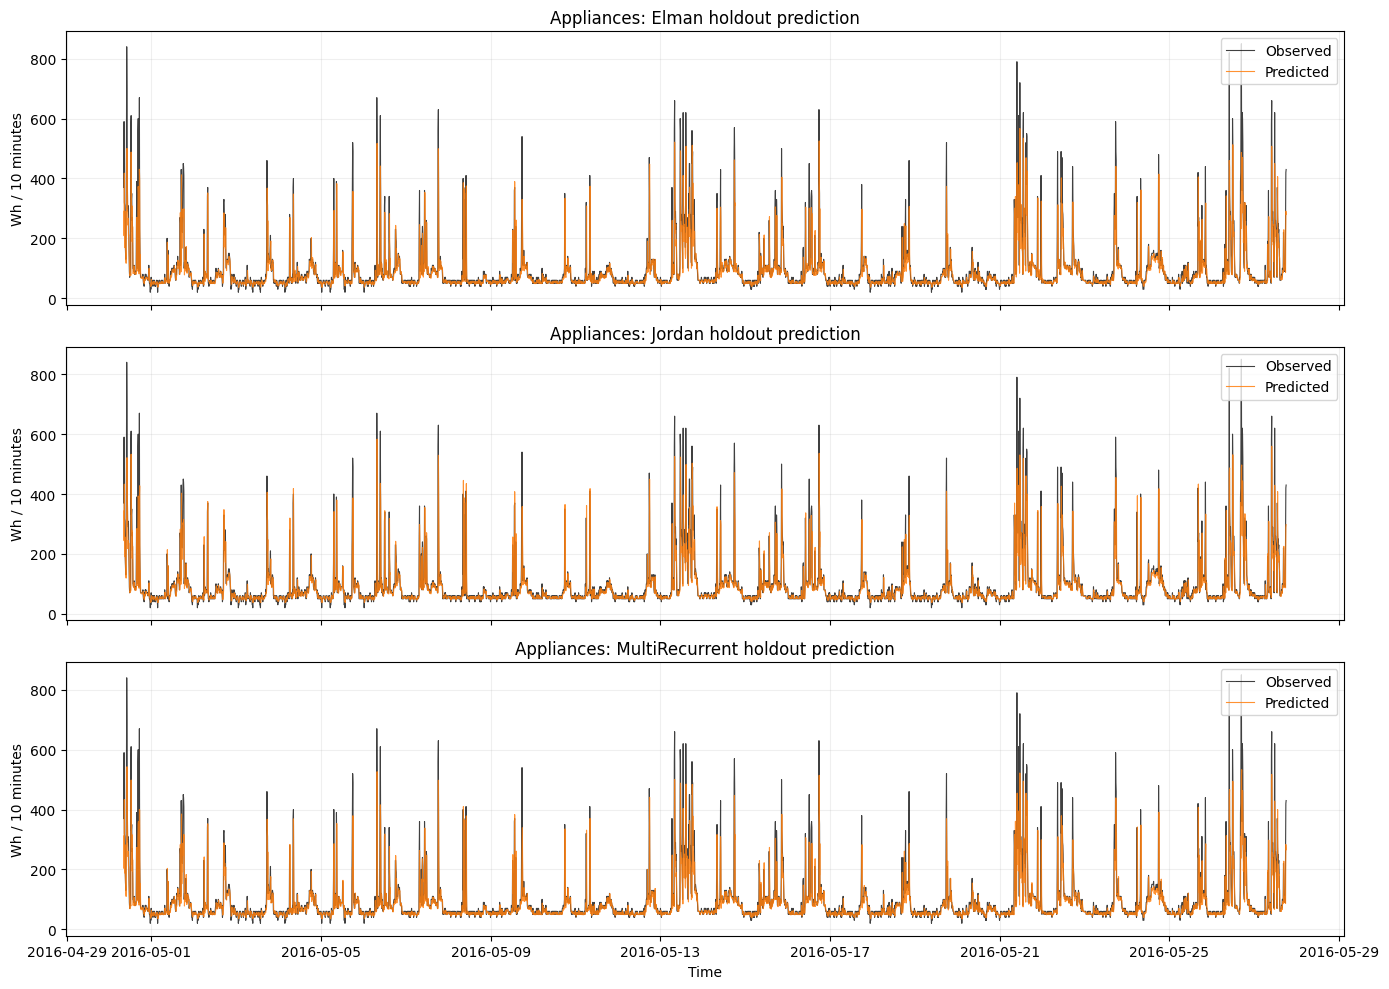

In [143]:
assert len(final_predictions) == 3

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
for ax, name in zip(axes, final_results['model']):
    record = final_predictions[name]
    ax.plot(record['dates'], record['actual'], color='black', linewidth=0.8,
            alpha=0.75, label='Observed')
    ax.plot(record['dates'], record['prediction'], color='tab:orange',
            linewidth=0.8, alpha=0.85, label='Predicted')
    ax.set_title(f'{dataset_name}: {name} holdout prediction')
    ax.set_ylabel(target_unit)
    ax.grid(alpha=0.2)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time' if not np.issubdtype(
    np.asarray(final_predictions[final_results.iloc[0]['model']]['dates']).dtype,
    np.number) else 'Sample')
fig.tight_layout()
plt.show()
